# 1.3.1 作用方向与反馈回路

## 学习目标与先修知识

- 解释反馈（feedback）回路中的正、负作用方向。
- 从边符号推出整个闭环的方向。
- 区分因果回路图（causal loop diagram）中的假设和支持这些假设的观测（observation）。

**先修知识**：[内部交换与整体守恒](../02-存量流量与守恒/02-内部交换与整体守恒.ipynb)；正负数乘法。

## 具体问题

设想温度偏离目标后，冷却作用增强；冷却越强，温度偏差越小。这两条关系连接成环：偏差影响冷却，冷却又返回影响偏差。

先用正负数追踪一次小的扰动。每条同向作用乘 +1，每条反向作用乘 −1。三个环的符号看起来不同，但负边数量怎样决定最终方向？这里符号不表示温度值的正负，也不表示“有益”或“有害”。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
loops = [[1,-1], [-1,-1], [1,1,-1]]
for signs in loops:
    returned = 1
    for sign in signs:
        returned *= sign
    print('沿边', signs, '返回的方向为', returned)

沿边 [1, -1] 返回的方向为 -1
沿边 [-1, -1] 返回的方向为 1
沿边 [1, 1, -1] 返回的方向为 -1


## 模型假设

箭头 X → Y 标“+”，表示在所考虑范围内、其他直接影响条件固定时，增加 X 会使 Y 相比原本更大；“−”表示更小。这是一项机制假设，需说明条件，不是只看两条同升同降曲线就能确认。

负反馈（negative feedback）让扰动沿环返回时受到反向作用；正反馈（positive feedback）则同向增强。符号图不说明作用强度或多久后生效，也没有给出一条确定的时间轨迹（trajectory）。

本节温度例子是人工调节模型（model）。设偏差 e 是温度减目标的差值，单位 °C；冷却作用 r 暂以每步改变的温度量表示。假设偏差对冷却为正向，冷却对偏差为反向，不涉及具体器官或个体生理参数（parameter）。

## 数学解释与推导

扰动经过正边保持方向，经过负边反向。一个含 m 条边的闭环方向就是各边符号相乘；负边数为奇数时为负，为偶数时为正。这里 m 只是在数箭头。

例如 e → r 为 +1，r → e 为 −1，乘积 −1。因此它是抵消偏差的反馈方向。**这不保证轨迹单调**：作用若使用过时信息或过强，可能越过目标。图中的箭头表示作用方向；接下来用逐步更新的规则观察偏差怎样变化。

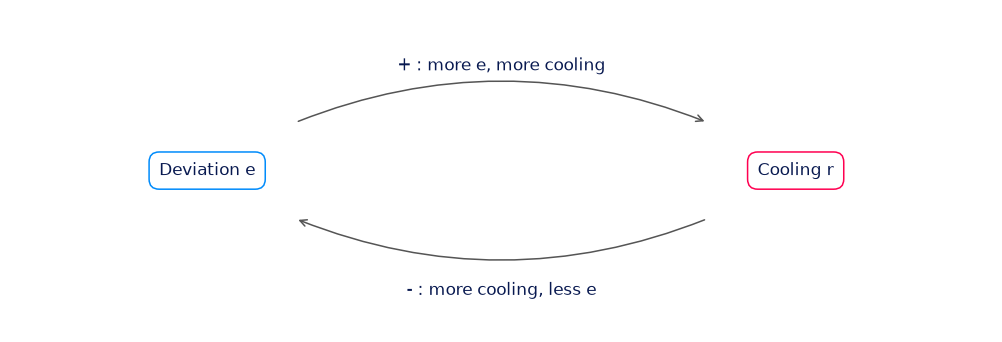

In [2]:
def loop_direction(signs):
    value = 1
    for sign in signs:
        value *= sign
    return value

assert loop_direction([1,-1]) == -1
assert loop_direction([-1,-1]) == 1
fig, ax = plt.subplots(figsize=(9,3))
ax.set(xlim=(0,10), ylim=(0,4))
ax.axis('off')
ax.text(2,2,'Deviation e',ha='center',va='center',bbox=dict(boxstyle='round,pad=.6',fc='white',ec='#008bfb'))
ax.text(8,2,'Cooling r',ha='center',va='center',bbox=dict(boxstyle='round,pad=.6',fc='white',ec='#ff0051'))
ax.annotate('',xy=(7.1,2.6),xytext=(2.9,2.6),arrowprops=dict(arrowstyle='->',connectionstyle='arc3,rad=-.2',color='#555555'))
ax.annotate('',xy=(2.9,1.4),xytext=(7.1,1.4),arrowprops=dict(arrowstyle='->',connectionstyle='arc3,rad=-.2',color='#555555'))
ax.text(5,3.25,'+ : more e, more cooling',ha='center')
ax.text(5,.45,'- : more cooling, less e',ha='center')
plt.show()

## 对照实验

现在增加一个旁路假设：散热同时增加失水。局部温度偏差变小，能否推出整个系统的所有指标都改善？用一个给定的小变化规则比较调节强弱，不推断真实人体反应。

In [3]:
initial_deviation, initial_loss = 2.0, 0.0
rows=[]
for action in [0, .5, 1]:
    new_deviation = initial_deviation - action
    new_loss = initial_loss + 2*action  # 人工比例，失水单位 U
    rows.append([action, new_deviation, new_loss])
display(Markdown(show_table(['冷却作用 / °C', '新偏差 / °C', '失水量 / U'],rows)))

| 冷却作用 / °C | 新偏差 / °C | 失水量 / U |
| --- | --- | --- |
| 0 | 2 | 0 |
| 0.5 | 1.5 | 1 |
| 1 | 1 | 2 |

## 结果解释

在所给规则下，冷却越强温度偏差越小，失水却越多。这说明“一个局部目标改善”与“所有变量改善”不是同一命题。

实际检验应记录同步的温度、失水及操作条件，并检查读数是否受共同测量偏移影响。这些观测可用来检验图中的作用关系。下一节用逐步调节规则比较过去信息如何改变结果。

[打开可视化与探索：反馈延迟与层级](http://127.0.0.1:8000/chapters/01-03-反馈、延迟与层级/explore/)

[本章导览](http://127.0.0.1:8000/chapters/01-03-反馈、延迟与层级/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：箭头上的正号不是“有益”

在因果回路图（causal loop diagram）中，箭头 X → Y 标“+”。正确解释是什么？

- **A.** X 大于零。
- **B.** X 增大时，在其他条件相同的局部关系假设下，Y 比原本更大。
- **C.** X 与 Y 的数值必然相同。
- **D.** 这条作用对健康有益。

[作答：箭头上的正号不是“有益”](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-signed-arrow)

### 第 2 题 · Python 计算题：沿一个闭环追踪作用方向

反馈（feedback）闭环中每条边以 +1 表示同向局部作用，−1 表示反向局部作用。返回整个闭环的符号。

**函数与代码模板**

```python
def solve(
    signs: list[int],
) -> int:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `signs` | `list[int]` | 沿一个已确认闭合的回路，依次列出的边符号。 | 无量纲 |

**返回值**

直接返回 loop_sign（int）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `loop_sign` | `int` | 所有边符号的乘积，只能为 +1 或 −1。 | 无量纲 |

**计算规则**

把所有符号相乘。正号表示扰动沿回路返回时同向，负号表示反向；该结果不判定响应快慢或长期行为。

**约束与边界**

- 所有数值均为有限数。
- 1 ≤ len(signs) ≤ 100；每项只为 1 或 −1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| signs | 沿一个已确认闭合的回路，依次列出的边符号。 | [1, 1, -1] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
signs = [1, 1, -1]

result = solve(signs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| loop_sign | 所有边符号的乘积，只能为 +1 或 −1。 | -1 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = -1
```

**样例解释**

前两条边保持作用方向，最后一条反转，因此返回方向为 −1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：沿一个闭环追踪作用方向](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-loop-sign)

### 第 3 题 · 多项选择题：负反馈能保证什么

一个假想温度调节环为：温度偏差升高 → 冷却作用增强 → 温度偏差减小。关于负反馈（negative feedback），哪些说法正确？

- **A.** 沿此闭环的总作用方向为负。
- **B.** 它保证任意延迟（delay）和强度下都平滑回到目标。
- **C.** 因果图是一组需要核对的机制假设，不能仅凭相关曲线认定。
- **D.** “负”表示这种机制一定有害。

[作答：负反馈能保证什么](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-negative-feedback)

### 第 4 题 · 单项选择题：局部改善与另一个变量的代价

在一个人工生理示意模型（model）中，散热作用增加会减小温度偏差，同时增大失水；补水可以减小失水。要区分“散热改善温度但加重失水”和“读数偏移造成表面改善”，哪项观测（observation）最有帮助？

- **A.** 只看调节装置是否启动。
- **B.** 只比较两张温度截图，不管时刻。
- **C.** 同时记录独立温度读数、物质收支（mass balance）与散热和补水条件，保持测量标定一致。
- **D.** 只选温度改善的实验，删除其余情况。

[作答：局部改善与另一个变量的代价](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-coupled-loops)

**进一步阅读**

[MIT 15.871 Assignment 3，D 部分](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)把目标差异与纠正行动联系起来。[Feedback Systems 第二版，第 1 章资料入口](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html)可用于进一步认识反馈。这里的符号实验与人工温度规则为本书自拟。